<div style="background-color: lightblue;text-align: center;line-height:2px; padding: 15px; border-radius: 5px; font-size:16px;">
    <h1><b>Fake News Detection</b></h1>
    <p><b>By:</b></p>
    <p>Deepak TM</p>
    <p>Umesh Goyal</p>
</div>

## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [12]:
#pip list | findstr "numpy pandas nltk spacy scipy pydantic wordcloud"

In [13]:
from IPython import display

In [14]:
# !pip install --upgrade numpy==1.26.4
# !pip install --upgrade pandas==2.2.2
# !pip install --upgrade nltk==3.9.1
# !pip install --upgrade spacy==3.7.5
# !pip install --upgrade scipy==1.12
# !pip install --upgrade pydantic==2.10.5
# !pip install wordcloud==1.9.4
# !python -m spacy download en_core_web_sm

# display.clear_output()

## Importing the necessary libraries

In [16]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations

In [17]:
## Change the display properties of pandas to max
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [19]:
# Import the first file - True.csv
true_data = pd.read_csv("True.csv")
# Import the second file - Fake.csv
fake_data = pd.read_csv("Fake.csv")

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [22]:
# Inspect the DataFrame with True News to understand the given data
true_data.head()

,title,text,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017"


In [23]:
# Inspect the DataFrame with Fake News to understand the given data
fake_data.head()

,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...","December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...","December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,"December 25, 2017"


In [24]:
true_data.describe()

,title,text,date
count,21417,21417,21417
unique,20826,21192,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,"December 20, 2017"
freq,14,8,182


In [25]:
# Print the column details for True News DataFrame
true_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [26]:
# Print the column details for Fake News Dataframe
fake_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [27]:
# Print the column names of both DataFrames
print (f"Column name of True Dataset: {true_data.columns.values}")
print (f"Column name of Fake Dataset: {fake_data.columns.values}")

Column name of True Dataset: ['title' 'text' 'date']
Column name of Fake Dataset: ['title' 'text' 'date']


In [28]:
print("TRUE DATA")
print(f"No of Column: {true_data.shape[1]}")
print(f"No of Rows: {true_data.shape[0]}")
print("FAKE DATA")
print(f"No of Column: {fake_data.shape[1]}")
print(f"No of Rows: {fake_data.shape[0]}")

TRUE DATA
No of Column: 3
No of Rows: 21417
FAKE DATA
No of Column: 3
No of Rows: 23523


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [30]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
true_data['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
fake_data['news_label'] = 0

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [32]:
# Combine the true and fake news DataFrames into a single DataFrame
merged_df = pd.concat([true_data, fake_data], axis=0)

In [33]:
# Display the first 5 rows of the combined DataFrame to verify the result
merged_df.sample(frac=1).reset_index(drop=True).head()

,title,text,date,news_label
0,Great! Vet Lives Matter To Trump Who Offered T...,Donald Trump took a question from a Wounded Wa...,"Oct 28, 2015",0
1,PRO-TRUMP ROCKER #TedNugent Fires Back at Comp...,Ted Nugent isn t having it! He s being compare...,"Jun 3, 2017",0
2,Congress passes funding bill averting governme...,WASHINGTON (Reuters) - The U.S. Congress appro...,"September 28, 2016",1
3,"Suicide attacks on restaurants, checkpoint, ki...",BAGHDAD (Reuters) - Three suicide attacks clai...,"September 14, 2017",1
4,'Glimmer of hope' seen for compromise U.S. gun...,WASHINGTON (Reuters) - U.S. senators pushed fo...,"June 21, 2016",1


In [34]:
print(f"Merged Row Number Matches with the Original Dataset Size: {(true_data.shape[0] + fake_data.shape[0]) == merged_df.shape[0]}")

Merged Row Number Matches with the Original Dataset Size: True


### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [36]:
# Check Presence of Null Values
merged_df.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [37]:
# Handle Rows with Null Values
merged_df.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [38]:
merged_df[merged_df.isnull().any(axis=1)].head()

,title,text,date,news_label
9731,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,We just discovered another reason NOT to suppo...,NaN,0
9732,NaN,NaN,NaN,0
12408,WOW! AMERICA IS UNDER ATTACK By These 187 Orga...,There have been many articles written about Ge...,NaN,0
12409,NaN,NaN,NaN,0
13364,A MUST READ! Here’s Why Voting For DONALD TRUM...,This is a must read for anyone who s undecided...,NaN,0


Currently dropping rows with all 3 values as NULL. 
> Yet to decide on what to do with the rows with only data as missing value.

In [40]:
merged_df.dropna(axis=0, thresh=3, inplace=True)

In [41]:
print("MERGED DATA")
print(f"No of Column: {merged_df.shape[1]}")
print(f"No of Rows: {merged_df.shape[0]}")

MERGED DATA
No of Column: 4
No of Rows: 44919


### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [43]:
merged_df

,title,text,date,news_label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017",1
...,...,...,...,...
23518,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,"January 16, 2016",0
23519,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,"January 16, 2016",0
23520,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,"January 15, 2016",0
23521,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,"January 14, 2016",0


In [44]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
merged_df['news_text'] = merged_df['title'] + " " + merged_df['text']
# Drop the irrelevant columns from the DataFrame as they are no longer needed
merged_df.drop(columns= "date", inplace= True)
# Display the first 5 rows of the updated DataFrame to check the result
merged_df.head()

,title,text,news_label,news_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1,Trump wants Postal Service to charge 'much mor...


## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [48]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
df_clean = pd.DataFrame(columns=["cleaned_text","lemmatized_text"])
# Add 'news_label' column to the new dataframe for topic identification
df_clean['news_label'] = merged_df['news_label']

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [50]:
# Write the function here to clean the text and remove all the unnecessary elements
def clean_text(text):
    # Convert to lower case
    text = text.lower()
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove words with numbers
    text = re.sub(r'\w*\d\w*', '', text)
    return text

#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [52]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean["cleaned_text"] = merged_df['news_text'].progress_apply(clean_text)

100%|██████████████████████████████████████████████████████████████████████████| 44919/44919 [00:19<00:00, 2361.93it/s]


In [53]:
df_clean

,cleaned_text,lemmatized_text,news_label
0,as us budget fight looms republicans flip thei...,NaN,1
1,us military to accept transgender recruits on ...,NaN,1
2,senior us republican senator let mr mueller do...,NaN,1
3,fbi russia probe helped by australian diplomat...,NaN,1
4,trump wants postal service to charge much more...,NaN,1
...,...,...,...
23518,mcpain john mccain furious that iran treated u...,NaN,0
23519,justice yahoo settles email privacy classactio...,NaN,0
23520,sunnistan us and allied ‘safe zone’ plan to ta...,NaN,0
23521,how to blow million al jazeera america finall...,NaN,0


### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [56]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags


#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [58]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
import nltk
from nltk.corpus import stopwords
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer

In [59]:
# Load spacy model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(stopwords.words('english'))

# def pos_tag_lemmatize(text):
#     doc = nlp(text)
#     tokens = []
#     for token in doc:
#         # Check if token is a noun (NN or NNS), not a stopword, and not punctuation
#         if (token.tag_ in ['NN', 'NNS']) and (token.text.lower() not in stop_words):
#             tokens.append(token.lemma_.lower())  # Lemmatize and convert to lowercase
#     return " ".join(tokens)

def batched_pos_tag_lemmatize(texts, batch_size=1000):
    results = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts), desc="Lemmatizing"):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.tag_ in ['NN', 'NNS'] and token.text.lower() not in stop_words and not token.is_punct
        ]
        results.append(" ".join(tokens))
    return results

In [60]:
df_clean["lemmatized_text"] = batched_pos_tag_lemmatize(df_clean["cleaned_text"].tolist())

Lemmatizing: 100%|███████████████████████████████████████████████████████████████| 44919/44919 [24:02<00:00, 31.15it/s]


In [61]:
df_clean

,cleaned_text,lemmatized_text,news_label
0,as us budget fight looms republicans flip thei...,budget fight script head faction month expansi...,1
1,us military to accept transgender recruits on ...,military transgender recruit people time milit...,1
2,senior us republican senator let mr mueller do...,job counsel investigation link trump election ...,1
3,fbi russia probe helped by australian diplomat...,probe diplomat trump campaign adviser diplomat...,1
4,trump wants postal service to charge much more...,trump service amazon shipment service ship pac...,1
...,...,...,...
23518,mcpain john mccain furious that iran treated u...,sailor century wire week mishap vessel water h...,0
23519,justice yahoo settles email privacy classactio...,email privacy classaction lawyer user century ...,0
23520,sunnistan us and allied ‘safe zone’ plan to ta...,zone plan booty century wireremember world non...,0
23521,how to blow million al jazeera america finall...,century wire history failure broadcast medium ...,0


### Save the Cleaned data as a csv file (Recommended)

In [63]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)

**Loading the saved data**

In [65]:
clear_df = pd.read_csv("clean_df.csv")

In [66]:
# Check the first few rows of the DataFrame
clear_df.head()

,cleaned_text,lemmatized_text,news_label
0,as us budget fight looms republicans flip thei...,budget fight script head faction month expansi...,1
1,us military to accept transgender recruits on ...,military transgender recruit people time milit...,1
2,senior us republican senator let mr mueller do...,job counsel investigation link trump election ...,1
3,fbi russia probe helped by australian diplomat...,probe diplomat trump campaign adviser diplomat...,1
4,trump wants postal service to charge much more...,trump service amazon shipment service ship pac...,1


In [67]:
# Check the dimensions of the DataFrame
clear_df.shape

(44919, 3)

In [68]:
# Check the number of non-null entries and data types of each column
clear_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44919 entries, 0 to 44918
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cleaned_text     44919 non-null  object
 1   lemmatized_text  44896 non-null  object
 2   news_label       44919 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [69]:
clear_df.dropna(subset="lemmatized_text", inplace=True)

## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [71]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn import model_selection

In [72]:
X = clear_df['lemmatized_text']
y = clear_df['news_label']
X_train, X_val, y_train, y_val = model_selection.train_test_split(X, y, train_size=0.7,
                                                                    random_state=42, stratify=y)

## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [76]:
# Add a new column to calculate the character length of cleaned news text
clear_df['cleaned_text_size'] = clear_df['cleaned_text'].apply(lambda x:len(x))
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
clear_df['lemmatized_text_size'] = clear_df['lemmatized_text'].apply(lambda x:len(x))

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

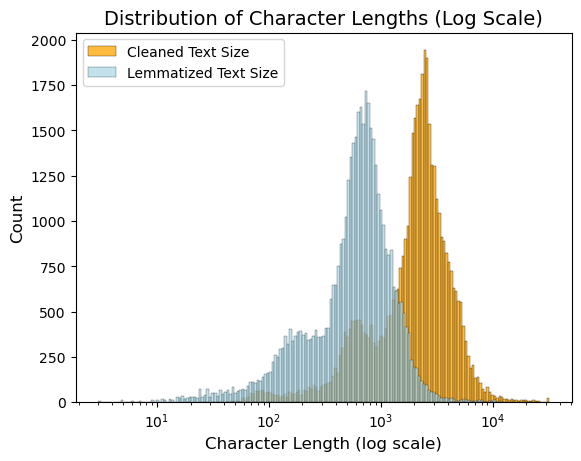

In [78]:
# Create a histogram plot to visualise character lengths
# Add histogram for cleaned news text
sns.histplot(data=clear_df, x='cleaned_text_size', log_scale=(True, False), label='Cleaned Text Size', color='orange')

# Add histogram for lemmatized news text with POS tags removed
sns.histplot(data=clear_df, x='lemmatized_text_size', log_scale=(True, False), label='Lemmatized Text Size', color='lightblue')

plt.title('Distribution of Character Lengths (Log Scale)', fontsize=14)
plt.xlabel('Character Length (log scale)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.legend()
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

In [81]:
!pip install pillow --force-reinstall
display.clear_output()

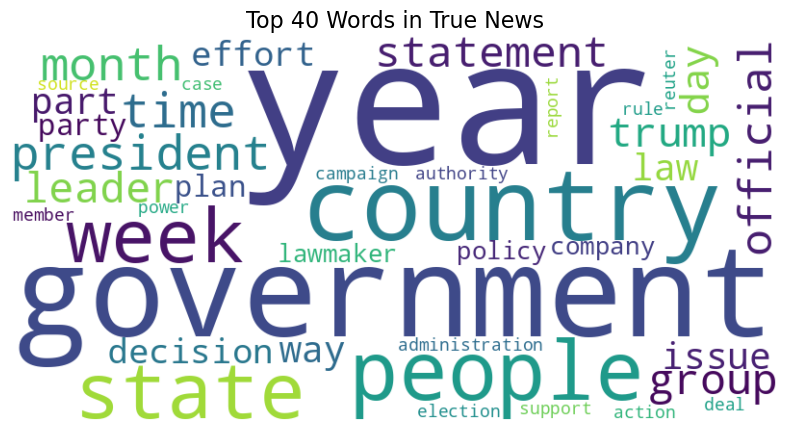

In [82]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
from wordcloud import WordCloud

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
true_news = clear_df[clear_df['news_label'] == 1]
true_text_data = ' '.join(true_news['lemmatized_text'].dropna().astype(str))
# Generate word cloud for True News
wordcloud = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='viridis').generate(true_text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No axis
plt.title('Top 40 Words in True News', fontsize=16)
plt.show()

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

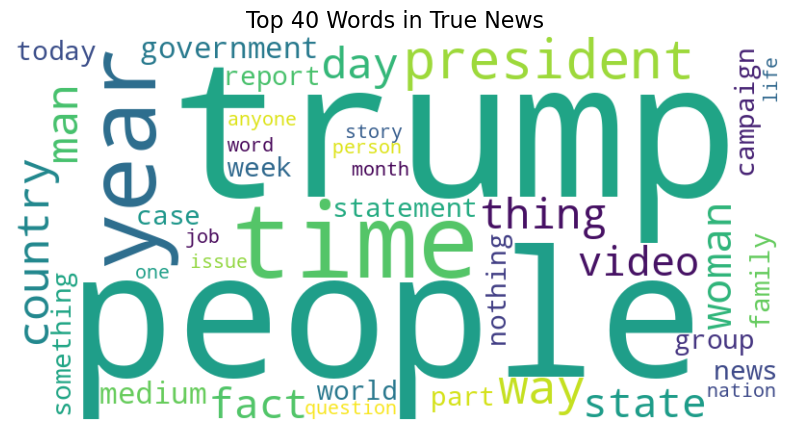

In [84]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
fake_news = clear_df[clear_df['news_label'] == 0]
fake_text_data = ' '.join(fake_news['lemmatized_text'].dropna().astype(str))
# Generate word cloud for Fake News
wordcloud = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='viridis').generate(fake_text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No axis
plt.title('Top 40 Words in True News', fontsize=16)
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [87]:
# Write a function to get the specified top n-grams
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, ngram_range=(1,1), n=None):
    # ngram_range => prefix word + word + suffix word
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vec.fit_transform([corpus])
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return pd.DataFrame(words_freq[:n], columns=['ngram', 'frequency'])

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [89]:
# Handle NaN values in the text data
true_text_data = re.sub(r'\s+', ' ', true_text_data).strip()
fake_text_data = re.sub(r'\s+', ' ', fake_text_data).strip()

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [92]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
get_top_ngrams(true_text_data, ngram_range=(1,1), n=10)

,ngram,frequency
0,trump,44759
1,state,20172
2,government,19847
3,year,18964
4,people,15394
5,election,14316
6,country,14086
7,official,13359
8,party,12886
9,president,11587


##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [94]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
get_top_ngrams(true_text_data, ngram_range=(2,2), n=10)

,ngram,frequency
0,trump campaign,2098
1,trump administration,1867
2,news conference,1377
3,request comment,1026
4,percent percent,1025
5,tax reform,1021
6,security force,1003
7,climate change,988
8,house representative,972
9,attorney general,917


##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [96]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
pd.set_option('display.max_colwidth', None)
get_top_ngrams(true_text_data, ngram_range=(10,10), n=10)

,ngram,frequency
0,statement twitter account realdonaldtrump potus opinion reuter statement accuracy realdonaldtrump,64
1,twitter statement twitter account realdonaldtrump potus opinion reuter statement accuracy,29
2,trump twitter statement twitter account realdonaldtrump potus opinion reuter statement,19
3,reporting editing article sap editorial staff sap involvement creation production,19
4,billionaire chair advocate privatization education chair child state level voucher,18
5,chair advocate privatization education chair child state level voucher family,18
6,advocate privatization education chair child state level voucher family child,18
7,privatization education chair child state level voucher family child school,18
8,education chair child state level voucher family child school expansion,18
9,chair child state level voucher family child school expansion charter,18


### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

In [99]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
get_top_ngrams(fake_text_data, ngram_range=(1,1), n=10)

,ngram,frequency
0,trump,59921
1,people,26428
2,president,16647
3,time,16066
4,year,15011
5,image,13933
6,state,12898
7,woman,11751
8,video,11587
9,campaign,11302


##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [101]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
get_top_ngrams(fake_text_data, ngram_range=(2,2), n=10)

,ngram,frequency
0,trump supporter,2213
1,trump campaign,1868
2,president trump,1822
3,century wire,1798
4,police officer,1688
5,image image,1584
6,law enforcement,1562
7,donald trump,1391
8,screen capture,1325
9,image trump,1127


##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



In [103]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
get_top_ngrams(fake_text_data, ngram_range=(10,10), n=10)

,ngram,frequency
0,talk radio custommade barfly philosopher moralist street corner evangelist savant,115
1,radio custommade barfly philosopher moralist street corner evangelist savant animal,115
2,custommade barfly philosopher moralist street corner evangelist savant animal rascalsjoin,113
3,barfly philosopher moralist street corner evangelist savant animal rascalsjoin host,113
4,tonight pm broadcast talk radio custommade bar fly philosopher moralist,88
5,pm broadcast talk radio custommade bar fly philosopher moralist street,88
6,broadcast talk radio custommade bar fly philosopher moralist street corner,88
7,talk radio custommade bar fly philosopher moralist street corner evangelist,88
8,radio custommade bar fly philosopher moralist street corner evangelist savant,88
9,custommade bar fly philosopher moralist street corner evangelist savant animal,88


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [107]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [109]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [112]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [114]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [117]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [119]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [122]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [124]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [126]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [129]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [131]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [133]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [136]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
from gensim.models import KeyedVectors
from gensim.downloader import load

word2vec_model = load('word2vec-google-news-300')

### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [138]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
def text_to_vector(text, model, vector_size=300):
    words = text.split()
    word_vectors = []

    for word in words:
        if word in model:
            word_vectors.append(model[word])
    
    if len(word_vectors) == 0:
        # If no word found in model, return a zero vector
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

## Extract the target variable for the training data and validation data
X_train_vectors = np.array([text_to_vector(text, word2vec_model) for text in X_train])
X_val_vectors = np.array([text_to_vector(text, word2vec_model) for text in X_val])

## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [144]:
## Initialise Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
## Train Logistic Regression model on training data
log_reg_model.fit(X_train_vectors, y_train)
## Predict on validation data
y_val_pred = log_reg_model.predict(X_val_vectors)

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [146]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Accuracy
print(f"accuracy = {round(accuracy_score(y_val, y_val_pred),4)}")
# Precision
print(f"precision = {round(precision_score(y_val, y_val_pred),4)}")
# Recall
print(f"recall = {round(recall_score(y_val, y_val_pred),4)}")
# F1 Score
print(f"f1 = {round(f1_score(y_val, y_val_pred),4)}")

accuracy = 0.9006
precision = 0.891
recall = 0.9019
f1 = 0.8964


In [147]:
# Classification Report
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7044
           1       0.89      0.90      0.90      6425

    accuracy                           0.90     13469
   macro avg       0.90      0.90      0.90     13469
weighted avg       0.90      0.90      0.90     13469



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [150]:
## Initialise Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
## Train Decision Tree model on training data
decision_tree_model.fit(X_train_vectors, y_train)
## Predict on validation data
y_val_pred_dt = decision_tree_model.predict(X_val_vectors)

##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [152]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Accuracy
print(f"accuracy = {round(accuracy_score(y_val, y_val_pred_dt),4)}")
# Precision
print(f"precision = {round(precision_score(y_val, y_val_pred_dt),4)}")
# Recall
print(f"recall = {round(recall_score(y_val, y_val_pred_dt),4)}")
# F1 Score
print(f"f1 = {round(f1_score(y_val, y_val_pred_dt),4)}")

accuracy = 0.8229
precision = 0.8236
recall = 0.8
f1 = 0.8116


In [153]:
# Classification Report
print(classification_report(y_val, y_val_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      7044
           1       0.82      0.80      0.81      6425

    accuracy                           0.82     13469
   macro avg       0.82      0.82      0.82     13469
weighted avg       0.82      0.82      0.82     13469



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [156]:
## Initialise Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
## Train Random Forest model on training data
random_forest_model.fit(X_train_vectors, y_train)
## Predict on validation data
y_val_pred_rf = random_forest_model.predict(X_val_vectors)

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [158]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
# Accuracy
print(f"accuracy = {round(accuracy_score(y_val, y_val_pred_rf),4)}")
# Precision
print(f"precision = {round(precision_score(y_val, y_val_pred_rf),4)}")
# Recall
print(f"recall = {round(recall_score(y_val, y_val_pred_rf),4)}")
# F1 Score
print(f"f1 = {round(f1_score(y_val, y_val_pred_rf),4)}")

accuracy = 0.9013
precision = 0.9059
recall = 0.8851
f1 = 0.8954


In [159]:
# Classification Report
print(classification_report(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      7044
           1       0.91      0.89      0.90      6425

    accuracy                           0.90     13469
   macro avg       0.90      0.90      0.90     13469
weighted avg       0.90      0.90      0.90     13469



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

This project successfully developed a semantic classification system for distinguishing true from fake news articles using Word2Vec embeddings. The methodology involved a comprehensive preprocessing pipeline focusing on key semantic units (nouns), followed by vector representation using a pre-trained Word2Vec model and training supervised classifiers.

Exploratory Data Analysis confirmed significant linguistic differences between the true and fake news corpora. The semantic features extracted through Word2Vec, combined with standard machine learning models, proved effective. Both Logistic Regression and Random Forest models demonstrated high classification performance on the validation set, achieving F1-scores around 90%, significantly outperforming the Decision Tree model. The Random Forest model showed marginally better performance in detecting fake news (class 0).

The approach effectively addressed the problem by leveraging the semantic meaning of the text, going beyond simple keyword matching, which is crucial for detecting nuanced misinformation. The relatively high performance suggests that this methodology is a promising direction for automated fake news detection.

**Limitations** included the simplified approach to document vectorization (simple averaging), reliance on a single pre-trained embedding model, and the restriction of text content to only nouns.

**Future work** could involve exploring more sophisticated embedding techniques, incorporating a wider range of linguistic features (e.g., verbs, adjectives, sentiment), experimenting with more complex model architectures (deep learning models), and evaluating the approach on diverse datasets to assess its robustness and generalizability across different domains and styles of news.